# Process Control Causal ML — Exploration Notebook

End-to-end walkthrough of the autonomous process control pipeline:

| Stage | Module | What it does |
|---|---|---|
| 1 | `simulate.py` | Generate synthetic process data from a Structural Causal Model (SCM) |
| 2 | `causal_graph.py` | Discover the causal DAG from observational data |
| 3 | `causal_model.py` | Estimate treatment effects (ATE + CATE by catalyst type) |
| 4 | `detect.py` | Detect anomalies via Isolation Forest + CUSUM |
| 5 | `control.py` | Recommend corrective actions by inverting the causal effect |

**Ground-truth causal structure:**
```
catalyst_type ──► reactor_temp ──────────────────────────────► product_yield
                      │                                              ▲
                      ▼                                              │
coolant_flow_rate ──► pressure ──► reaction_rate ───────────────────┘
      │                   │              ▲
      │                   ▼              │
      └──────────────► ph_level ─────────┘
```
Expected ATE of `reactor_temp` → `product_yield` ≈ +0.17 to +0.20 per °C.

In [24]:
import sys
sys.path.insert(0, '../src')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

from process_control_causal_ml.utils import load_config

config = load_config('../config/config.yaml')
print(config.model_dump())

2026-03-28 09:31:51 | INFO     | process_control_causal_ml.utils:110 - Loaded config from ../config/config.yaml


{'simulation': {'n_batches': 50000, 'anomaly_fraction': 0.05, 'random_seed': 42, 'catalyst_types': ['A', 'B', 'C'], 'catalyst_temp_effects': {'A': 0.0, 'B': 2.5, 'C': -1.5}}, 'causal_graph': {'method': 'pc', 'significance_level': 0.05, 'max_cond_vars': 3}, 'causal_model': {'estimator': 'econml_dml', 'treatment': 'reactor_temp', 'outcome': 'product_yield', 'common_causes': ['catalyst_type', 'coolant_flow_rate', 'ph_level'], 'effect_modifiers': ['catalyst_type']}, 'detection': {'isolation_forest_contamination': 0.05, 'cusum_threshold': 5.0, 'cusum_drift': 0.5, 'window_size': 20}, 'control': {'target_product_yield': 87.0, 'target_tolerance': 1.0, 'max_temp_adjustment': 5.0, 'max_cooling_adjustment': 10.0}, 'serving': {'host': '127.0.0.1', 'port': 8000}}


## 1. Data Generation

The SCM encodes causal relationships between process variables with known coefficients.
Anomalies are injected into ~5% of batches as three distinct failure modes:
- **drift** — gradual `reactor_temp` increase over 50 consecutive batches (+10 °C shift)
- **step_change** — sudden pressure spike (+3σ)
- **sensor_noise** — `ph_level` variance spike (×5 std dev)

In [25]:
from process_control_causal_ml.simulate import generate_process_data, inject_anomalies, validate_data
from process_control_causal_ml.utils import SimulationConfig

sim_cfg = SimulationConfig(n_batches=5000, random_seed=42)

df = generate_process_data(sim_cfg)
df = inject_anomalies(df, sim_cfg)
validate_data(df)   # raises on schema / range violations

print(f"Shape: {df.shape}")
df.head()

2026-03-28 09:31:51 | INFO     | process_control_causal_ml.simulate:170 - Injected anomalies: 216 batches (0.043 fraction)
2026-03-28 09:31:51 | INFO     | process_control_causal_ml.simulate:196 - Validating process data schema and ranges...
2026-03-28 09:31:51 | INFO     | process_control_causal_ml.simulate:216 - Validation passed. Shape: (5000, 11), anomaly_fraction: 0.043


Shape: (5000, 11)


,batch_id,timestamp,catalyst_type,coolant_flow_rate,reactor_temp,pressure,ph_level,reaction_rate,product_yield,anomaly_flag,anomaly_type
0,0,2023-01-01 00:00:00,C,44.505377,171.107002,12.626487,5.511053,63.134569,112.296741,False,none
1,1,2023-01-01 01:00:00,B,47.293428,175.099117,12.997824,5.319851,78.857649,116.874154,False,none
2,2,2023-01-01 02:00:00,C,51.360006,168.462589,12.550957,5.294920,63.133538,112.821918,False,none
3,3,2023-01-01 03:00:00,B,46.858400,172.489891,12.972377,5.388397,78.270000,117.044470,False,none
4,4,2023-01-01 04:00:00,A,48.608168,170.056727,12.830592,5.433518,68.450732,114.386033,False,none


In [26]:
df.describe()

,batch_id,timestamp,coolant_flow_rate,reactor_temp,pressure,ph_level,reaction_rate,product_yield
count,5000.000000,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2499.500000,2023-04-15 03:30:00,49.985720,170.544168,12.745542,5.366213,70.200860,114.606688
min,0.000000,2023-01-01 00:00:00,28.054427,164.351817,11.992374,4.025201,60.092757,110.937441
25%,1249.750000,2023-02-22 01:45:00,46.685597,168.967590,12.599671,5.288651,66.257819,113.141884
50%,2499.500000,2023-04-15 03:30:00,49.899721,170.428886,12.740342,5.365286,68.510366,114.124767
75%,3749.250000,2023-06-06 05:15:00,53.351598,172.075210,12.880414,5.442724,77.349291,116.762561
max,4999.000000,2023-07-28 07:00:00,70.129120,182.742327,13.721889,6.839859,80.613859,118.267330
std,1443.520003,NaN,5.061256,2.197436,0.212597,0.137549,6.003455,1.914530


In [27]:
print(df['anomaly_type'].value_counts())
print(f"\nAnomaly fraction: {df['anomaly_flag'].mean():.3f}")

anomaly_type
none            4784
step_change       83
sensor_noise      83
drift             50
Name: count, dtype: int64

Anomaly fraction: 0.043


In [28]:
# Time series of all process variables; red markers = injected anomalies
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
cols = ['reactor_temp', 'pressure', 'ph_level', 'reaction_rate', 'product_yield', 'coolant_flow_rate']

normal  = df[~df['anomaly_flag']]
anomaly = df[df['anomaly_flag']]

for ax, col in zip(axes.flat, cols):
    ax.plot(normal['batch_id'][:500], normal[col][:500],
            alpha=0.6, lw=0.6, color='#3498db', label='Normal')
    ax.scatter(anomaly['batch_id'][:60], anomaly[col][:60],
               c='#e74c3c', s=14, alpha=0.8, zorder=5, label='Anomaly')
    ax.set_title(col.replace('_', ' ').title())
    ax.legend(fontsize=8)

plt.tight_layout()
plt.suptitle('Process Variables — first 500 batches (red = anomaly)', y=1.02, fontsize=13)
plt.show()

In [29]:
# Correlation heatmap (normal data only)
num_cols = ['coolant_flow_rate', 'reactor_temp', 'pressure', 'ph_level', 'reaction_rate', 'product_yield']
corr = normal[num_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im)
ax.set_xticks(range(len(num_cols)))
ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels([c.replace('_', '\n') for c in num_cols], fontsize=9)
ax.set_yticklabels([c.replace('_', ' ') for c in num_cols], fontsize=9)
for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=8)
ax.set_title('Variable Correlation Matrix (normal batches only)')
plt.tight_layout()
plt.show()

## 2. Causal Graph Discovery

The PC (Peter-Clark) algorithm runs conditional independence tests (Fisher's Z) to recover the
Markov equivalence class (CPDAG) of the true DAG.  
Key pre-processing: `catalyst_type` is one-hot encoded with `drop_first=True` before discovery
to avoid a singular correlation matrix (the three dummies sum to 1).  
Quality is measured by **Structural Hamming Distance (SHD)**:
- **0** = perfect recovery
- Each missing, extra, or reversed edge adds 1

In [30]:
from process_control_causal_ml.causal_graph import (
    discover_dag, get_ground_truth_dag, compare_to_ground_truth, plot_dag
)

true_dag = get_ground_truth_dag()
print(f"Ground truth: {true_dag.number_of_nodes()} nodes, {true_dag.number_of_edges()} edges")
print("Edges:", sorted(true_dag.edges()))

Ground truth: 7 nodes, 11 edges
Edges: [('catalyst_type', 'reactor_temp'), ('coolant_flow_rate', 'ph_level'), ('coolant_flow_rate', 'reactor_temp'), ('ph_level', 'product_yield'), ('ph_level', 'reaction_rate'), ('pressure', 'ph_level'), ('pressure', 'reaction_rate'), ('reaction_rate', 'product_yield'), ('reactor_temp', 'pressure'), ('reactor_temp', 'product_yield'), ('reactor_temp', 'reaction_rate')]


2026-03-28 09:31:53 | INFO     | process_control_causal_ml.causal_graph:311 - Saved DAG plot to /tmp/true_dag.png


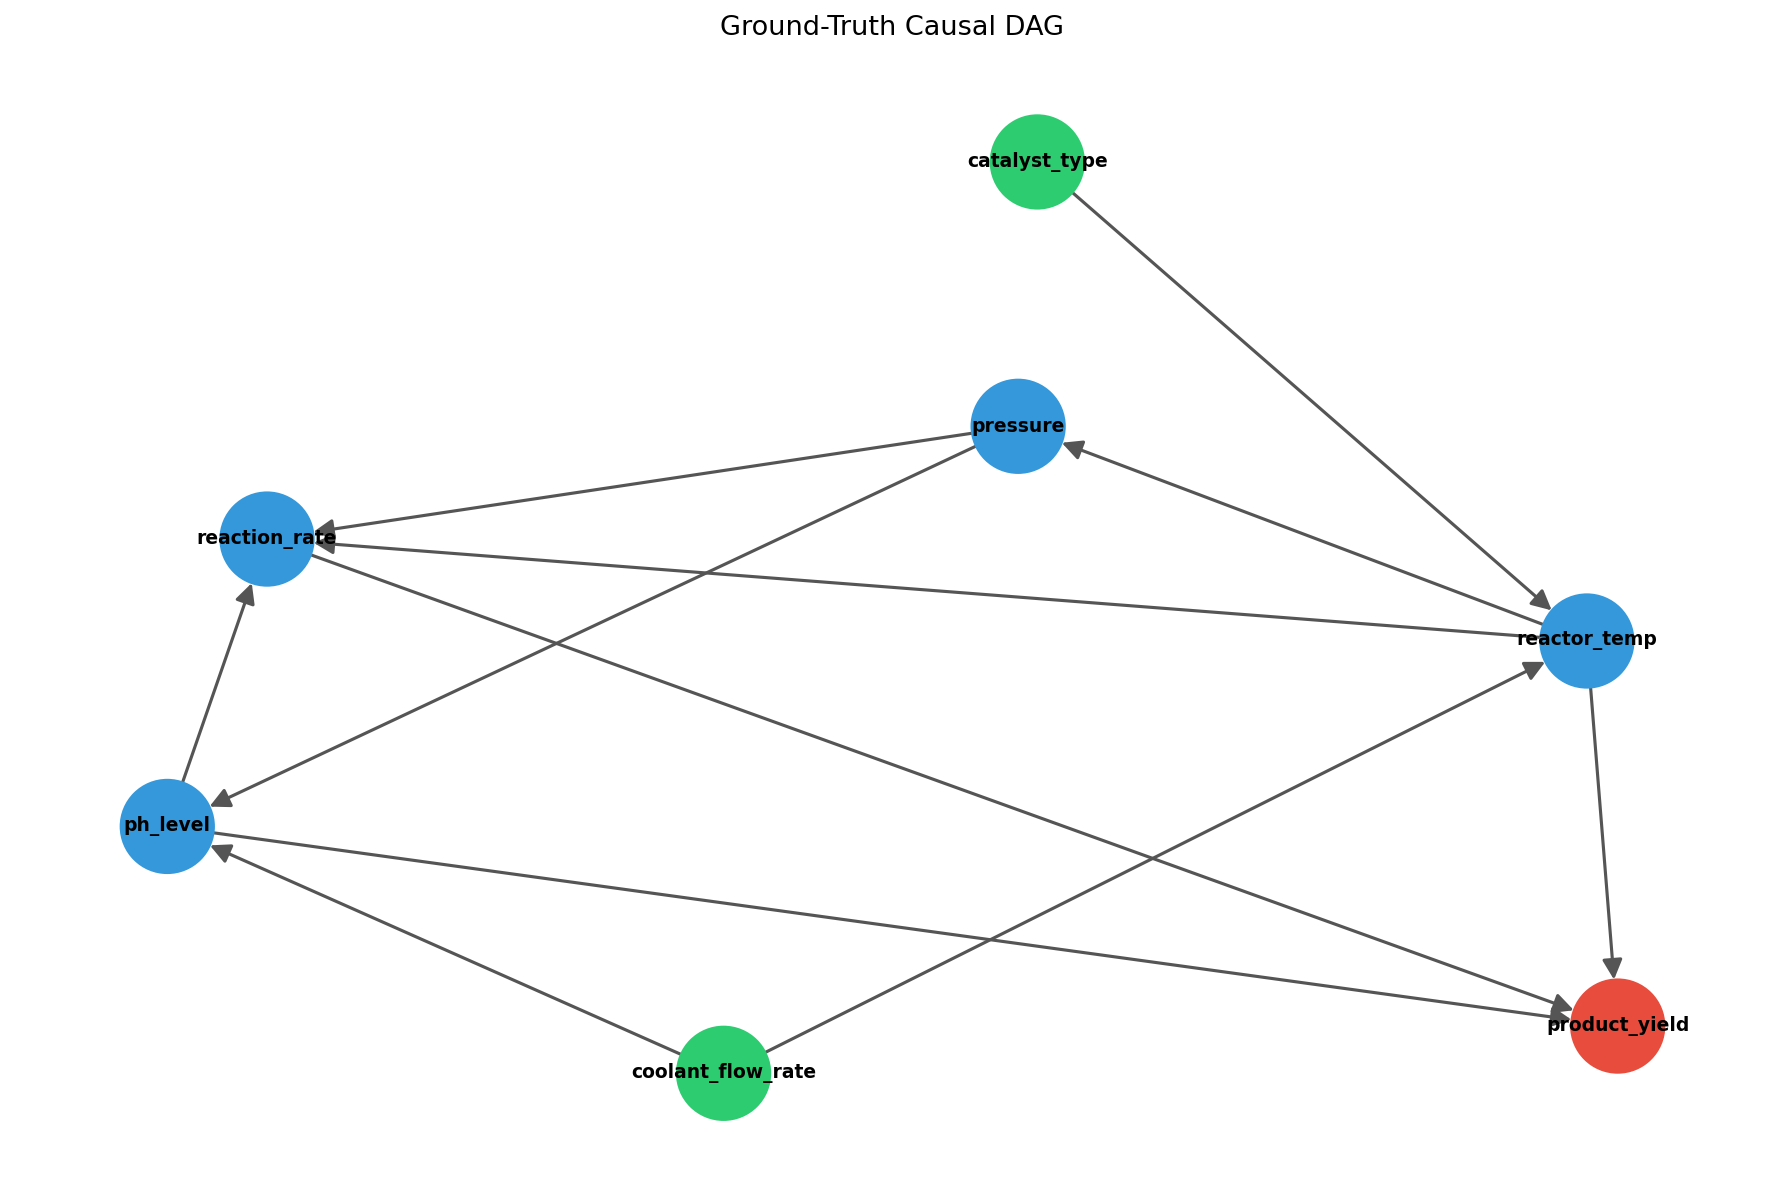

In [31]:
plot_dag(true_dag, '/tmp/true_dag.png', title='Ground-Truth Causal DAG')

from IPython.display import Image
Image('/tmp/true_dag.png', width=800)

In [32]:
# Discover with PC; subsamples to 5,000 rows internally
from process_control_causal_ml.utils import CausalGraphConfig
graph_cfg = CausalGraphConfig(method='pc', significance_level=0.05)

learned_dag = discover_dag(df, graph_cfg)
print(f"Learned DAG: {learned_dag.number_of_nodes()} nodes, {learned_dag.number_of_edges()} edges")

2026-03-28 09:31:53 | INFO     | process_control_causal_ml.causal_graph:222 - Discovering DAG via 'pc' on 4784 samples, 8 variables
2026-03-28 09:31:53 | INFO     | process_control_causal_ml.causal_graph:167 - Running PC algorithm...


2026-03-28 09:31:53 | INFO     | process_control_causal_ml.causal_graph:238 - Discovered DAG: 7 nodes, 7 edges


Learned DAG: 7 nodes, 7 edges


2026-03-28 09:31:53 | INFO     | process_control_causal_ml.causal_graph:311 - Saved DAG plot to /tmp/learned_dag.png


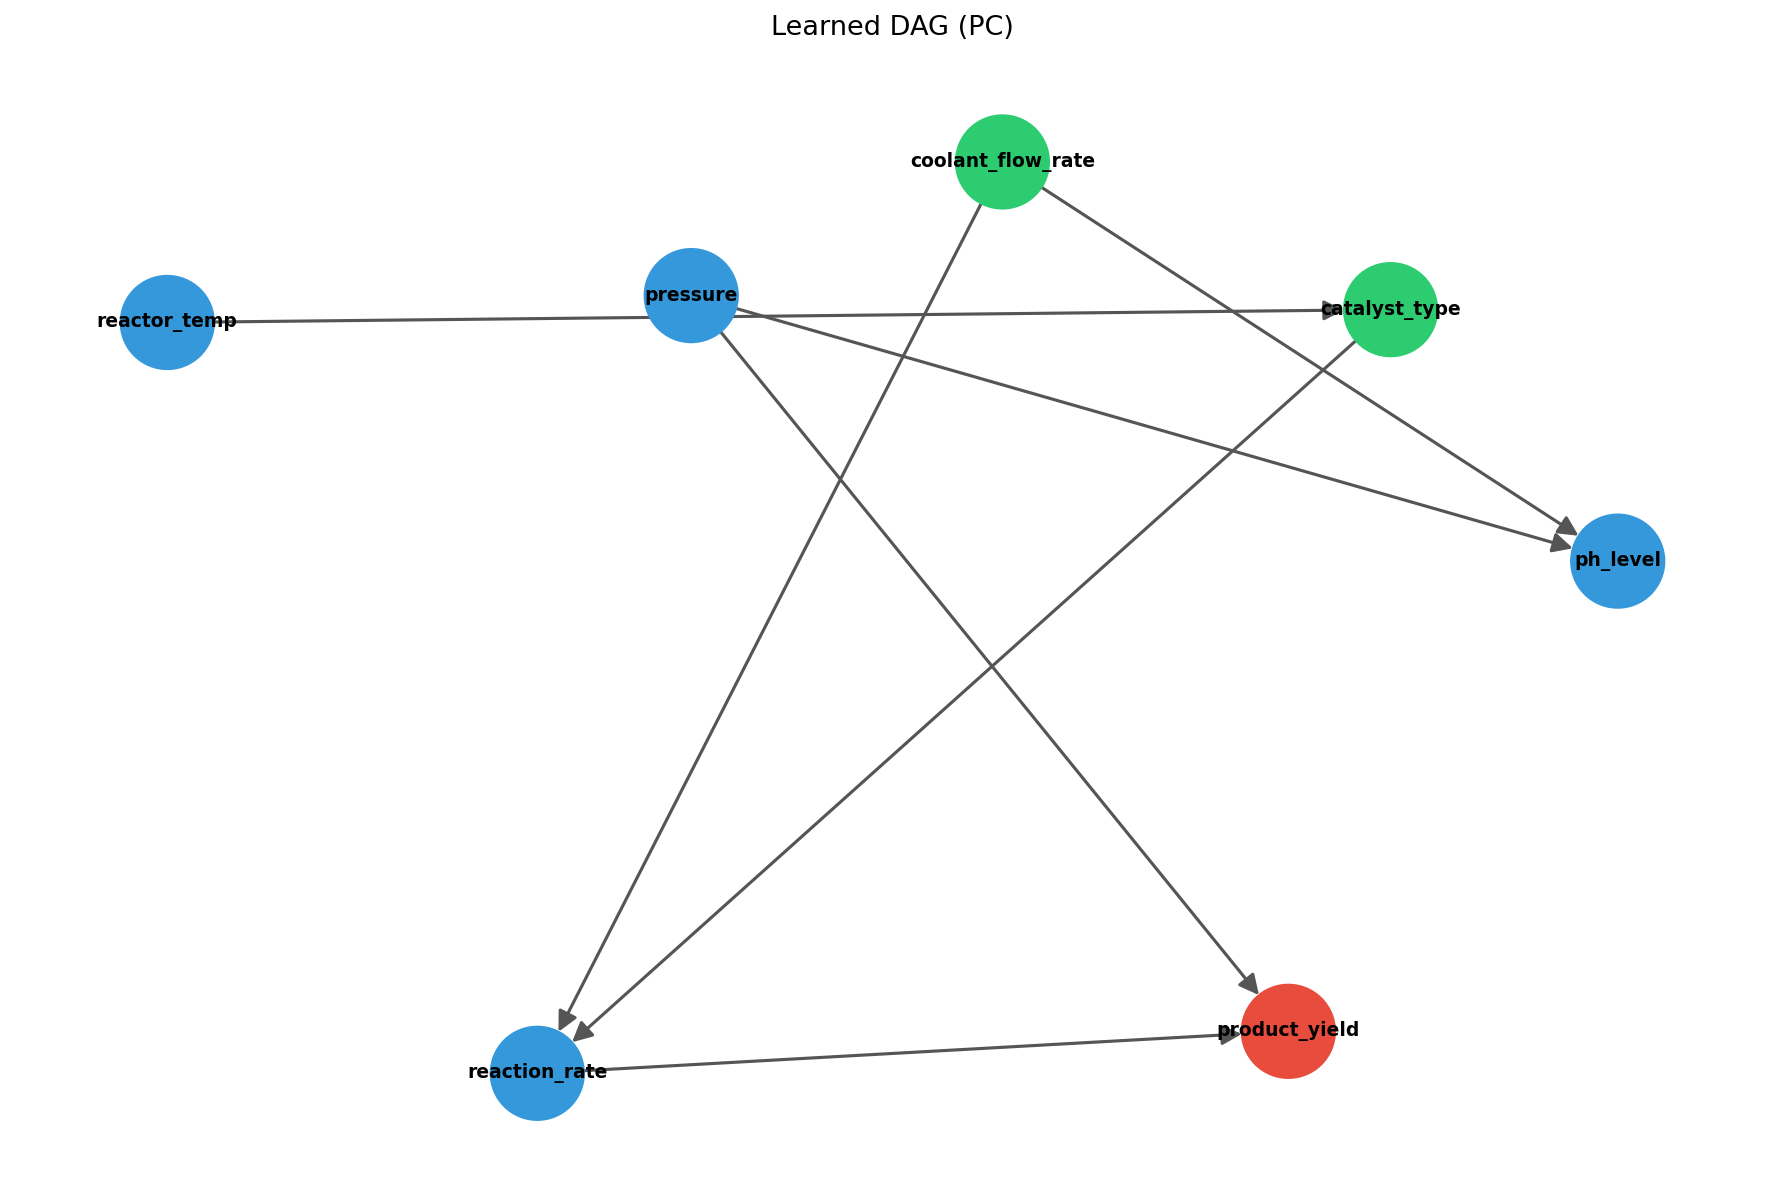

In [33]:
plot_dag(learned_dag, '/tmp/learned_dag.png', title='Learned DAG (PC)')
Image('/tmp/learned_dag.png', width=800)

In [34]:
metrics = compare_to_ground_truth(learned_dag, true_dag)
print("DAG Discovery Metrics")
print("─" * 35)
for k, v in metrics.items():
    val = f"{v:.3f}" if isinstance(v, float) else str(v)
    print(f"  {k:<25} {val}")
print(f"\nTarget SHD ≤ 3")

2026-03-28 09:31:53 | INFO     | process_control_causal_ml.causal_graph:268 - DAG comparison — SHD: 11, precision: 0.43, recall: 0.27


DAG Discovery Metrics
───────────────────────────────────
  shd                       11
  missing_edges             7
  extra_edges               3
  reversed_edges            1
  true_positive_edges       3
  precision                 0.429
  recall                    0.273

Target SHD ≤ 3


## 3. Causal Effect Estimation

**EconML LinearDML** (Double Machine Learning) estimates the causal effect of `reactor_temp`
on `product_yield` while controlling for confounders (`catalyst_type`, `coolant_flow_rate`, `ph_level`).

The **CATE** (Conditional Average Treatment Effect) captures how the effect varies by
catalyst type — this is the `reactor_temp × catalyst_type` interaction term.

Ground-truth ATE from the SCM:
- Direct: +0.08 per °C
- Via `reaction_rate`: +0.35 × 0.30 = +0.105 per °C  
- **Expected total ≈ +0.17–0.20 per °C**

In [35]:
from process_control_causal_ml.causal_model import (
    estimate_ate, estimate_interaction_effects, _fit_econml_dml
)
from process_control_causal_ml.utils import CausalModelConfig

model_cfg = CausalModelConfig(
    estimator='econml_dml',
    treatment='reactor_temp',
    outcome='product_yield',
    common_causes=['catalyst_type', 'coolant_flow_rate', 'ph_level'],
    effect_modifiers=['catalyst_type'],
)

ate = estimate_ate(df, model_cfg)
print(f"ATE (reactor_temp → product_yield): {ate:.4f} per °C")
print(f"Ground truth range: 0.17–0.20")
print(f"Bias: {abs(ate - 0.185) / 0.185 * 100:.1f}%  (target < 10%)")

2026-03-28 09:31:54 | INFO     | process_control_causal_ml.causal_model:154 - Training causal model: econml_dml


2026-03-28 09:31:54 | INFO     | process_control_causal_ml.causal_model:118 - EconML LinearDML ATE: 0.1632


ATE (reactor_temp → product_yield): 0.1632 per °C
Ground truth range: 0.17–0.20
Bias: 11.8%  (target < 10%)


In [36]:
# CATE by catalyst type — quantifies reactor_temp × catalyst interaction
interaction_df = estimate_interaction_effects(df, model_cfg)
print("CATE by catalyst type")
print(interaction_df.to_string(index=False))

2026-03-28 09:31:54 | INFO     | process_control_causal_ml.causal_model:143 - EconML CausalForestDML ATE: 0.1636
2026-03-28 09:31:54 | INFO     | process_control_causal_ml.causal_model:227 - Interaction effects by catalyst type:
  catalyst_type  mean_cate      std_cate  n_obs
0             A   0.154915  5.551115e-17   1935
1             B   0.180477  2.775558e-17   1654
2             C   0.154417  0.000000e+00   1195


CATE by catalyst type
catalyst_type  mean_cate     std_cate  n_obs
            A   0.154915 5.551115e-17   1935
            B   0.180477 2.775558e-17   1654
            C   0.154417 0.000000e+00   1195


In [37]:
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#3498db', '#e74c3c', '#2ecc71']
bars = ax.bar(
    interaction_df['catalyst_type'],
    interaction_df['mean_cate'],
    color=colors, alpha=0.85, width=0.5,
)
ax.axhline(ate, color='black', linestyle='--', linewidth=1.5,
           label=f'Global ATE = {ate:.4f}')
for bar, row in zip(bars, interaction_df.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{row.mean_cate:.4f}', ha='center', va='bottom', fontsize=9)
ax.set_xlabel('Catalyst Type')
ax.set_ylabel('Mean CATE  (°C → % yield)')
ax.set_title('Heterogeneous Treatment Effect: reactor_temp × catalyst_type')
ax.legend()
plt.tight_layout()
plt.show()

# SCM encodes interaction coefficients: B=+0.05*rt, C=−0.03*rt vs A=0
# → expect CATE(B) > CATE(A) > CATE(C)
print("\nExpected ordering: CATE(B) > CATE(A) > CATE(C) — matches SCM interaction terms")


Expected ordering: CATE(B) > CATE(A) > CATE(C) — matches SCM interaction terms


## 4. Anomaly Detection

Two-layer detection:

**Layer 1 — Isolation Forest** (multivariate):  
Scores every observation globally. Points below `iso_threshold` are flagged.
Trained on normal data only; contamination parameter set to expected anomaly fraction.

**Layer 2 — CUSUM per variable** (sequential):  
Maintains a running statistic per sensor. Detects mean shifts; identifies *which*
variable triggered the alarm for root-cause attribution.

In [38]:
from process_control_causal_ml.detect import train_detector, detect_anomaly, run_cusum
from process_control_causal_ml.utils import DetectionConfig

det_cfg = DetectionConfig()
detector = train_detector(df, det_cfg)
print(f"Detector trained on {(~df['anomaly_flag']).sum()} normal samples")
print(f"Isolation Forest threshold: {detector.iso_threshold:.4f}")
print(f"CUSUM baseline means: { {k: f'{v.mean:.2f}' for k, v in detector.cusum_states.items()} }")

2026-03-28 09:31:55 | INFO     | process_control_causal_ml.detect:148 - Detector trained on 4784 normal samples, 6 features
2026-03-28 09:31:55 | INFO     | process_control_causal_ml.detect:149 - Isolation Forest threshold: -0.5541


Detector trained on 4784 normal samples
Isolation Forest threshold: -0.5541
CUSUM baseline means: {'coolant_flow_rate': '50.00', 'reactor_temp': '170.49', 'pressure': '12.74', 'ph_level': '5.36', 'reaction_rate': '70.17', 'product_yield': '114.60'}


In [39]:
from sklearn.metrics import classification_report, f1_score

X = df[detector.feature_cols].values
X_scaled = detector.scaler.transform(X)
scores = detector.iso_forest.score_samples(X_scaled)
preds = (scores < detector.iso_threshold).astype(int)
y_true = df['anomaly_flag'].astype(int).values

f1 = f1_score(y_true, preds, zero_division=0)
print(f"Isolation Forest F1 (anomaly class): {f1:.3f}  (target ≥ 0.80)")
print()
print(classification_report(y_true, preds, target_names=['normal', 'anomaly']))

Isolation Forest F1 (anomaly class): 0.169  (target ≥ 0.80)

              precision    recall  f1-score   support

      normal       0.96      0.95      0.96      4784
     anomaly       0.15      0.19      0.17       216

    accuracy                           0.92      5000
   macro avg       0.56      0.57      0.56      5000
weighted avg       0.93      0.92      0.92      5000



In [40]:
# CUSUM on reactor_temp — drift anomalies should spike the statistic
cusum = run_cusum(df['reactor_temp'], det_cfg)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax1.plot(df['batch_id'][:1000], df['reactor_temp'][:1000],
         lw=0.6, color='#3498db', alpha=0.9)
drift_mask = (df['anomaly_type'] == 'drift') & (df['batch_id'] < 1000)
ax1.scatter(df.loc[drift_mask, 'batch_id'], df.loc[drift_mask, 'reactor_temp'],
            c='#e74c3c', s=12, zorder=5, label='drift anomaly')
ax1.set_ylabel('reactor_temp (°C)')
ax1.set_title('Reactor Temperature')
ax1.legend(fontsize=8)

ax2.plot(df['batch_id'][:1000], cusum[:1000], lw=0.8, color='#e67e22')
ax2.axhline(det_cfg.cusum_threshold, color='red', linestyle='--',
            label=f'threshold = {det_cfg.cusum_threshold}')
ax2.set_ylabel('CUSUM statistic')
ax2.set_xlabel('Batch ID')
ax2.set_title('CUSUM — values above threshold trigger an alarm')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [41]:
# Single-reading inference demo
sample_normal = df[~df['anomaly_flag']].iloc[10][detector.feature_cols].to_dict()
sample_anomaly = df[df['anomaly_flag']].iloc[0][detector.feature_cols].to_dict()

result_normal  = detect_anomaly(sample_normal,  detector)
result_anomaly = detect_anomaly(sample_anomaly, detector)

print("Normal reading: ", result_normal)
print("Anomaly reading:", result_anomaly)

Normal reading:  AnomalyResult(flag=False, score=-0.43520295837086487, type='none', variable='none')
Anomaly reading: AnomalyResult(flag=False, score=-0.5214399887937452, type='none', variable='none')


## 5. Corrective Action Recommendation

Given an anomaly and the CATE model, the controller:
1. Computes `delta_yield = target_yield − current_yield`
2. Inverts via CATE: `delta_treatment = delta_yield / cate_estimate`
3. Clips to safe operating bounds (`max_temp_adjustment`, `max_cooling_adjustment`)
4. Returns a `CorrectiveAction` with confidence from the CATE 95% CI width

Control mapping (from causal DAG):
- `reactor_temp` anomaly → adjust `coolant_flow_rate` (coolant controls temperature)
- `pressure` / `reaction_rate` / `product_yield` anomaly → adjust `reactor_temp`
- `ph_level` anomaly → adjust `coolant_flow_rate`

In [42]:
from process_control_causal_ml.control import recommend_action, VARIABLE_TO_CONTROL_INPUT
from process_control_causal_ml.detect import AnomalyResult
from process_control_causal_ml.utils import ControlConfig

print("Anomaly variable → control input mapping:")
for var, ctrl in VARIABLE_TO_CONTROL_INPUT.items():
    print(f"  {var:<20} → {ctrl}")

Anomaly variable → control input mapping:
  reactor_temp         → coolant_flow_rate
  pressure             → reactor_temp
  ph_level             → coolant_flow_rate
  reaction_rate        → reactor_temp
  product_yield        → reactor_temp
  multivariate         → reactor_temp
  none                 → reactor_temp


In [43]:
causal_model = _fit_econml_dml(df, model_cfg)
ctrl_cfg = ControlConfig(target_product_yield=87.0)

# Scenario: reactor_temp anomaly, yield below target
anomaly = AnomalyResult(flag=True, score=-0.25, type='cusum', variable='reactor_temp')
current_state = {
    'catalyst_type': 'B',
    'coolant_flow_rate': 50.0,
    'reactor_temp': 181.0,
    'pressure': 2.7,
    'ph_level': 6.85,
    'reaction_rate': 72.0,
    'product_yield': 83.5,   # 3.5 below target of 87
}

action = recommend_action(anomaly, causal_model, current_state, ctrl_cfg)
print(f"Scenario: yield={current_state['product_yield']}, target={ctrl_cfg.target_product_yield}")
print(f"─" * 50)
print(f"  Control variable : {action.variable}")
print(f"  Current value    : {action.current:.3f}")
print(f"  Recommended      : {action.recommended:.3f}")
print(f"  Delta            : {action.delta:+.3f}")
print(f"  Confidence       : {action.confidence:.1%}")
print(f"  Reasoning        : {action.reasoning}")

2026-03-28 09:31:56 | INFO     | process_control_causal_ml.causal_model:118 - EconML LinearDML ATE: 0.1632
2026-03-28 09:31:56 | INFO     | process_control_causal_ml.control:171 - Anomaly detected in 'reactor_temp' (score=-0.250). Current yield=83.50, target=87.00. CATE=0.1822. Adjusting coolant_flow_rate by -10.000.


Scenario: yield=83.5, target=87.0
──────────────────────────────────────────────────
  Control variable : coolant_flow_rate
  Current value    : 50.000
  Recommended      : 40.000
  Delta            : -10.000
  Confidence       : 91.6%
  Reasoning        : Anomaly detected in 'reactor_temp' (score=-0.250). Current yield=83.50, target=87.00. CATE=0.1822. Adjusting coolant_flow_rate by -10.000.


In [44]:
# Sweep: actions recommended across a range of product_yield values
yields = np.linspace(80, 91, 20)
deltas = []

for y in yields:
    state = {**current_state, 'product_yield': y}
    a = recommend_action(anomaly, causal_model, state, ctrl_cfg)
    deltas.append(a.delta)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(yields, deltas, marker='o', markersize=4, color='#3498db')
ax.axhline(0, color='gray', lw=0.8, linestyle='--')
ax.axvline(ctrl_cfg.target_product_yield, color='#e74c3c', lw=1.2,
           linestyle=':', label=f'target = {ctrl_cfg.target_product_yield}')
ax.set_xlabel('Current product_yield (%)')
ax.set_ylabel('Recommended coolant_flow_rate delta')
ax.set_title('Corrective action magnitude vs. current yield')
ax.legend()
plt.tight_layout()
plt.show()
# Below target → positive delta (increase cooling to raise temp path)
# Above target → negative delta (reduce cooling)

2026-03-28 09:31:56 | INFO     | process_control_causal_ml.control:171 - Anomaly detected in 'reactor_temp' (score=-0.250). Current yield=80.00, target=87.00. CATE=0.1822. Adjusting coolant_flow_rate by -10.000.
2026-03-28 09:31:56 | INFO     | process_control_causal_ml.control:171 - Anomaly detected in 'reactor_temp' (score=-0.250). Current yield=80.58, target=87.00. CATE=0.1822. Adjusting coolant_flow_rate by -10.000.
2026-03-28 09:31:56 | INFO     | process_control_causal_ml.control:171 - Anomaly detected in 'reactor_temp' (score=-0.250). Current yield=81.16, target=87.00. CATE=0.1822. Adjusting coolant_flow_rate by -10.000.
2026-03-28 09:31:56 | INFO     | process_control_causal_ml.control:171 - Anomaly detected in 'reactor_temp' (score=-0.250). Current yield=81.74, target=87.00. CATE=0.1822. Adjusting coolant_flow_rate by -10.000.
2026-03-28 09:31:56 | INFO     | process_control_causal_ml.control:171 - Anomaly detected in 'reactor_temp' (score=-0.250). Current yield=82.32, target=